In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from glob import glob
from tqdm import tqdm
import xarray as xr
import os, sys
import scipy
import pandas as pd
from scipy.ndimage import gaussian_filter
from sklearn.decomposition import PCA
from scipy import stats

from scipy import interpolate

from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

# from cinplaAnalysis.utils import *
import quantities as pq
%matplotlib inline

In [2]:
from icsd import StandardCSD, DeltaiCSD, StepiCSD

/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/icsd.py:1158: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  if f_type is not 'identity' and f_order is None:


In [3]:
import matplotlib

font = {'size'   : 12}

matplotlib.rc('font', **font)

In [4]:
matplotlib.rcParams['savefig.pad_inches'] = 0

In [5]:
def plotFig(ax,csd,breaks=None,absmax=None,timeLimited=False,plotCB=True,xlabels=False,title=None):

    if breaks is not None:
        for b in breaks:
            ax.plot([0,3000],[b,b],c='k')

    if absmax is None:
        absmax = np.max(np.abs(csd))

    rms = np.mean(np.sqrt(csd**2))
    
    #im = ax.imshow(np.array(csd)/rms, origin='lower',cmap='bwr_r',vmin=-0.1,vmax=.1)#, vmin =-absmax,vmax=absmax, cmap='bwr_r')
    im = ax.imshow(np.array(csd), origin='lower', vmin =-absmax,vmax=absmax, cmap='bwr_r')
    ax.axis(ax.axis('tight'))

    if plotCB:
        cb = plt.colorbar(im, ax=ax)
        cb.formatter.set_powerlimits((0,0))

                # Get the scientific notation text (e.g. 1e3)
        offset = cb.ax.yaxis.get_offset_text()
        
        # Move it: x > 1 pushes right of colorbar, y > 1 pushes above
        offset.set_x(5)
        offset.set_y(1.2)


    ax.set_yticklabels([])

    if xlabels:
        ax.set_xticks([0,50],labels=['0','50'])
        # ax.set_xlabel('Time (ms)')
    else:
        ax.set_xticklabels([])

    if timeLimited:
        ax.set_xlim([50,100])
    else:
        ax.set_xlim([0,50])

    if title:
        plt.title(title)

    plt.tight_layout()

In [6]:
def produce_iCSD(data,lfpIdx,diam):
    
    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    sigma = 0.277 * pq.S / pq.m                         # [S/m] or [1/(ohm*m)]
    sigma_top = 0.277 * pq.S / pq.m                     # [S/m] or [1/(ohm*m)]
    
    # Input dictionaries for each method
    
    step_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':20E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam,'tol':1e-12
    }
    
    
    icsd_high = StepiCSD(**step_input_high)


    return icsd_high

    

In [7]:
def produce_iCSD_all(data,lfpIdx,diam):
    
    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    sigma = 0.277 * pq.S / pq.m                         # [S/m] or [1/(ohm*m)]
    sigma_top = 0.277 * pq.S / pq.m                     # [S/m] or [1/(ohm*m)]
    
    # Input dictionaries for each method
    
    step_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':20E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam,
        'tol':1e-12
    }
    
    step_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':40E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam,
        'tol':1e-12
    }
    
    step_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':80E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam,
        'tol':1e-12
    }
    
    step_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':160E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam,
        'tol':1e-12
    }
     
    icsd_high = StepiCSD(**step_input_high)
    icsd_low = StepiCSD(**step_input_low)
    icsd_low_half = StepiCSD(**step_input_low_half)
    icsd_low_quarter = StepiCSD(**step_input_low_quarter)


    return icsd_high, icsd_low, icsd_low_half, icsd_low_quarter

In [8]:
def produce_sCSD(data,lfpIdx,diam):
    
    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    sigma = 0.277 * pq.S / pq.m                         # [S/m] or [1/(ohm*m)]
    sigma_top = 0.277 * pq.S / pq.m                     # [S/m] or [1/(ohm*m)]
    
    # Input dictionaries for each method
    
    
    std_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }   
    
    
    icsd_high_std = StandardCSD(**std_input_high)

    return icsd_high_std

In [9]:
def produce_oCSD(data,lfp_idx,disk_fullDensity_idx):

    ### Calculates oCSD for 40, 80, and 160 um electrode spacing, with rho of 500 um, by taking the sum of neighboring electrodes in the 20 um case

    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    objective_disk_full_highRes = data[:,disk_fullDensity_idx] # oCSD, 20 um spacing

    
    return objective_disk_full_highRes

In [10]:
def produce_oCSD_all(data,lfp_idx,disk_fullDensity_idx):

    ### Calculates oCSD for 40, 80, and 160 um electrode spacing, with rho of 500 um, by taking the sum of neighboring electrodes in the 20 um case

    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    objective_disk_full_highRes = data[:,disk_fullDensity_idx] # oCSD, 20 um spacing

    objective_disk_full_lowRes = np.zeros_like(totalLFPLowRes)
    objective_disk_half_lowRes = np.zeros_like(totalLFPLowResHalf)
    objective_disk_quarter_lowRes = np.zeros_like(totalLFPLowResQuarter)
    
    for l in range(objective_disk_full_lowRes.shape[1]):
        if l == 0:
            objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l+1]
        elif l == objective_disk_full_lowRes.shape[1]-1:
            objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]
        else:
            objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]+.5*objective_disk_full_highRes[:,2*l+1]
    
    for l in range(objective_disk_half_lowRes.shape[1]):
        if l == 0:
            objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l+1]
        elif l == objective_disk_half_lowRes.shape[1]-1:
            objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]
        else:
            objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]+.5*objective_disk_full_lowRes[:,2*l+1]
    
    for l in range(objective_disk_quarter_lowRes.shape[1]):
        if l == 0:
            objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l+1]
        elif l == objective_disk_quarter_lowRes.shape[1]-1:
            objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]
        else:
            objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]+.5*objective_disk_half_lowRes[:,2*l+1]

    return objective_disk_full_highRes, objective_disk_full_lowRes, objective_disk_half_lowRes, objective_disk_quarter_lowRes

In [11]:
hro = np.load('/mnt/c/Users/tharayil/Downloads/csd_paper/radii/total.npy')[50:-1]

In [12]:
from scipy.signal import convolve
def filterFunction(csd,order,sigma):
    coeffs = []
    for i in range(order):
        bn = np.exp(-0.5*((i-(order-1)/2)/(sigma*(order-1)/2))**2)
        coeffs.append(bn)

    coeffs = np.array(coeffs)
    coeffsSum = np.array([np.sum(coeffs)])

    coeffs /= coeffsSum

    filteredSignal = csd/csd.units
    for i in range(csd.shape[1]):
        filteredSignal[:,i] = convolve(csd[:,i],coeffs,mode='same')

    return filteredSignal*csd.units

In [13]:
def twoD_correlation(a, b):
    """
    Compute the normalized 2D cross-correlation between two arrays.
    Result values range from -1 (anticorrelated) to 1 (perfectly correlated).
    """
    a = a.astype(float)
    b = b.astype(float)
    # a[np.where(a>10)]=10
    # a[np.where(a<-10)]=-10

    # b[np.where(b>10)]=10
    # b[np.where(b<-10)]=-10
    
    a_mean = a.mean()
    b_mean = b.mean()
    num = np.sum((a - a_mean) * (b - b_mean))
    den = np.sqrt(np.sum((a - a_mean)**2) * np.sum((b - b_mean)**2))

    return num/den

In [30]:
highResOriginal = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/total_4.npy')/4
highResNoRecurrent = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noRecurrentConnecvitity_50um/total_4.npy')/4#[1500:1550] # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um
highResNoActive = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_withNoise_50um/total_4.npy')# Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um
noNoise_50 = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noNoise_50um/total.npy')
noNoiseNoActive_50 = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_50um/total.npy')


lfpIdx = np.arange(101) 

icsd_high_original_200 = produce_iCSD(highResOriginal,lfpIdx,400e-6*pq.m)


diam = 100E-6 * pq.m                              # [m]

icsd_high_original_50 = produce_iCSD(highResOriginal,lfpIdx,diam)
icsd_high_noRecurrent_50, icsd_low_noRecurrent_50, icsd_half_noRecurrent_50, icsd_quarter_noRecurrent_50 = produce_iCSD_all(highResNoRecurrent,lfpIdx,diam)
icsd_high_NoActive_50, icsd_low_NoActive_50, icsd_half_NoActive_50, icsd_quarter_NoActive_50 = produce_iCSD_all(highResNoActive,lfpIdx,diam)
icsd_high_NoNoise_50, icsd_low_NoNoise_50, icsd_half_NoNoise_50, icsd_quarter_NoNoise_50 = produce_iCSD_all(noNoise_50,lfpIdx,diam)
icsd_high_NoNoiseNoActive_50, icsd_low_NoNoiseNoActive_50, icsd_half_NoNoiseNoActive_50, icsd_quarter_NoNoiseNoActive_50 = produce_iCSD_all(noNoiseNoActive_50,lfpIdx,diam)



In [31]:
original_csd = np.load('/mnt/c/Users/tharayil/Downloads/csd_paper/radii/total.npy')[50:-1]

idx_100 = np.arange(101,202) # Indices in the output file for objective disk CSD with 100 um rho
idx_50 = np.arange(202,303) # Indices in the output file for objective disk CSD with 500 um rho
idx_20 = np.arange(303,404) # Indices in the output file for objective disk CSD with 20 um rho


# Note that the order for these is intentionally weird since we combined a bunch of files to make the electrode weights file
ocsd_original_200 = produce_oCSD(highResOriginal,lfpIdx,np.arange(202,303))
ocsd_original_50 = produce_oCSD(highResOriginal,lfpIdx,np.arange(303,404))


idx_100 = np.arange(101) # Indices in the output file for objective disk CSD with 100 um rho
idx_50 = np.arange(101,202) # Indices in the output file for objective disk CSD with 500 um rho
idx_20 = np.arange(101) # Indices in the output file for objective disk CSD with 20 um rho


# Here we recalculate oCSD for noRecurrent using the averaged data from noRecurrent_50um
ocsd_noRecurrent_50 = produce_oCSD(highResNoRecurrent,lfpIdx,np.arange(303,404))

ocsd_noNoise_50 = produce_oCSD(noNoise_50,lfpIdx,np.arange(303,404))

ocsd_noNoiseNoActive_50, ocsd_low_noNoiseNoActive_50, ocsd_half_noNoiseNoActive_50, ocsd_quarter_noNoiseNoActive_50 = produce_oCSD_all(noNoiseNoActive_50,lfpIdx,np.arange(303,404))

NoActive_All = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_withNoise_50um/total_3.npy')
ocsd_NoActive_50, ocsd_low_NoActive_50, ocsd_half_NoActive_50, ocsd_quarter_NoActive_50 = produce_oCSD_all(NoActive_All,lfpIdx,np.arange(303,404))
                                

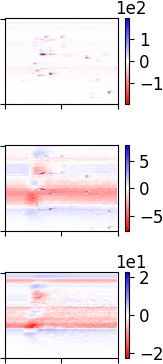

In [32]:
fig, ax = plt.subplots(3,1,figsize=(2,4))
from scipy.ndimage import gaussian_filter1d
plotFig(ax[0],icsd_high_original_200.get_csd())
plotFig(ax[1],filterFunction(icsd_high_original_200.get_csd(),order=19,sigma=5))
plotFig(ax[2],ocsd_original_200.T*1e-12/(np.pi*(200*1e-6)**2*20e-6))
plt.tight_layout()

plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/v3Figures/filtered.png',dpi=600)


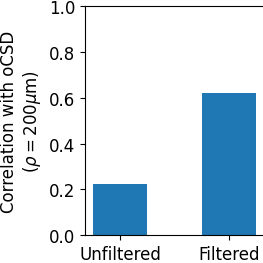

In [34]:
originalCorr = twoD_correlation(icsd_high_original_200.get_csd(),ocsd_original_200.T)
filteredCorr = twoD_correlation(filterFunction(icsd_high_original_200.get_csd(),order=19,sigma=5),ocsd_original_200.T)

fig,ax = plt.subplots(figsize=(3,3))
ax.bar(np.arange(2), [originalCorr, filteredCorr],width=0.5)
ax.set_xticks(np.arange(2))
ax.set_xticklabels(['Unfiltered','Filtered'])
ax.set_ylabel('Correlation with oCSD\n'+ r'($\rho=200\mu$m)')
ax.set_ylim([0,1])
plt.tight_layout()

plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/v3Figures/filteredBar.png',dpi=600)


In [69]:
twoD_correlation(filterFunction(icsd_high_original_200.get_csd(),order=50,sigma=20),ocsd_original_200.T)
# twoD_correlation(icsd_high_original_200.get_csd(),ocsd_original_200.T)

array(0.28973161) * dimensionless

In [14]:
def getMeanCorrelation(icsd,ocsd):

    from scipy.stats import wasserstein_distance

    correlations = []
    distances = []
    icsdVal = icsd.get_csd()

    rms = np.mean(np.sqrt(icsdVal**2))

    icsdVal /=  rms

    rms = np.mean(np.sqrt(ocsd**2))

    ocsd /= rms

    for i in range(icsdVal.shape[1]):
        distances.append(wasserstein_distance(icsdVal[:,i],ocsd.T[:,i]))
        correlations.append(np.corrcoef(icsdVal[:,i],ocsd.T[:,i])[0,1])

    return np.mean(correlations), np.mean(distances)

In [37]:
def getMeanCorrelation(a, b):
    """
    Compute the normalized 2D cross-correlation between two arrays.
    Result values range from -1 (anticorrelated) to 1 (perfectly correlated).
    """
    a = a.get_csd().astype(float)
    b = b.T
    b = b.astype(float)
    a_mean = a.mean()
    b_mean = b.mean()
    num = np.sum((a - a_mean) * (b - b_mean))
    den = np.sqrt(np.sum((a - a_mean)**2) * np.sum((b - b_mean)**2))

    return num/den, None

In [16]:
np.sum(np.sqrt(np.random.rand(100)**2))

np.float64(46.24149512625964)

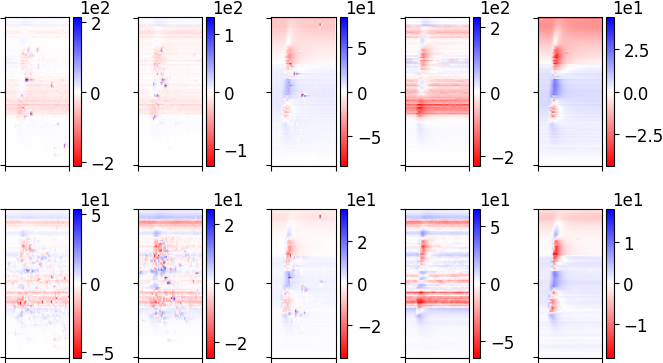

In [35]:
fig, axes = plt.subplots(2,5,figsize=(7,4))

plotFig(axes[0][0],icsd_high_original_50.get_csd())
plotFig(axes[1][0],ocsd_original_50.T*1e-12/(np.pi*(50*1e-6)**2*20e-6))

plotFig(axes[0][1],icsd_high_noRecurrent_50.get_csd())
plotFig(axes[1][1],ocsd_noRecurrent_50.T*1e-12/(np.pi*(50*1e-6)**2*20e-6))

plotFig(axes[0][2],icsd_high_NoNoise_50.get_csd())
plotFig(axes[1][2],ocsd_noNoise_50.T*1e-12/(np.pi*(50*1e-6)**2*20e-6))

plotFig(axes[0][3],icsd_high_NoActive_50.get_csd())
plotFig(axes[1][3],ocsd_NoActive_50.T*1e-12/(np.pi*(50*1e-6)**2*20e-6))

plotFig(axes[0][4],icsd_high_NoNoiseNoActive_50.get_csd())
plotFig(axes[1][4],ocsd_noNoiseNoActive_50.T*1e-12/(np.pi*(50*1e-6)**2*20e-6))

plt.tight_layout()

plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/v3Figures/explainPriorWork.png',dpi=600)


In [22]:
correlationNoNoise

array(0.74223914) * dimensionless

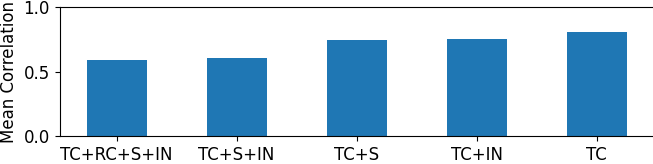

In [38]:
correlationOriginal, distanceOriginal = getMeanCorrelation(icsd_high_original_50,ocsd_original_50)
correlationNoRecurrent, distanceNoRecurrent = getMeanCorrelation(icsd_high_noRecurrent_50,ocsd_noRecurrent_50)
# _, distanceNoActive = getMeanCorrelation(icsd_high_NoActive_100,ocsd_noActive_100)
correlationNoNoise, distanceNoNoise = getMeanCorrelation(icsd_high_NoNoise_50,ocsd_noNoise_50)
correlationNoActive, distanceNoActive = getMeanCorrelation(icsd_high_NoActive_50,ocsd_NoActive_50)

correlationNoActiveNoNoise, distanceNoActiveNoNoise = getMeanCorrelation(icsd_high_NoNoiseNoActive_50,ocsd_noNoiseNoActive_50)

fig,ax = plt.subplots(figsize=(7,2))
ax.bar(np.arange(5), [correlationOriginal, correlationNoRecurrent, correlationNoNoise, correlationNoActive, correlationNoActiveNoNoise],width=0.5)
ax.set_xticks(np.arange(5))
ax.set_xticklabels(['TC+RC+S+IN','TC+S+IN','TC+S','TC+IN', 'TC'])
ax.set_ylabel('Mean Correlation')
plt.ylim([0,1])
plt.tight_layout()
plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/v3Figures/explainPriorWork_bar.png',dpi=600)


In [34]:
correlationNoRecurrent

np.float64(0.6188061486009674)